In [2]:
# Cell 1: Import libraries
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from preprocessing import preprocess_pipeline
from utils import plot_class_distribution

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
# Cell 2: Run the full preprocessing pipeline
# ------------------------------------------------------------
print("Running full preprocessing pipeline...")
X_train_df, y_train, X_test_df, test_ids, encoders, scaler = preprocess_pipeline(data_path='../data/raw/')

print(f"\nTraining set shape: {X_train_df.shape}")
print(f"Test set shape: {X_test_df.shape}")
print(f"Target variable shape: {y_train.shape}")
print(f"Test IDs: {len(test_ids)}")

# Merge features and target for initial EDA
df = pd.concat([X_train_df.copy(), y_train.rename('TARGET')], axis=1)

print(f"\nMerged dataset shape for EDA: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}... (showing first 10)")

Running full preprocessing pipeline...
Starting preprocessing pipeline...
Loading datasets...
Loaded 8 datasets
Training samples: 307511
Test samples: 48744

Merging all datasets...
Aggregating bureau data...
Aggregating previous applications...
Aggregating installments...
Aggregating credit card balance...
Aggregating POS cash balance...
Merged train shape: (307511, 250)
Merged test shape: (48744, 249)

Handling missing values...
Dropping 85 columns with >50.0% missing values
Final shape after handling missing values: (307511, 163)

Handling missing values...
Dropping 73 columns with >50.0% missing values
Final shape after handling missing values: (48744, 175)

Encoding categorical features...
Label encoded 4 binary columns
One-hot encoded 7 columns
Label encoded 2 high-cardinality columns
Final shape after encoding - Train: (307511, 191), Test: (48744, 191)

Creating polynomial features (degree=2) for top 10 features...
Added 65 polynomial features
New shape - Train: (307511, 256), T

In [5]:
# Cell 3: Basic data exploration
# ------------------------------------------------------------
print("=" * 80)
print("BASIC DATA INFORMATION")
print("=" * 80)
print(f"\nTotal rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nTarget variable distribution:")
print(df['TARGET'].value_counts())
print(f"\nTarget percentage:")
print(df['TARGET'].value_counts(normalize=True) * 100)

BASIC DATA INFORMATION

Total rows: 307,511
Total columns: 257

Target variable distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentage:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [6]:
# ------------------------------------------------------------
# Cell 4: Missing values analysis
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print(f"\nColumns with missing values: {len(missing_df)}")
if len(missing_df) > 0:
    print("\nTop 15 columns with most missing values:")
    print(missing_df.head(15).to_string(index=False))
else:
    print("\nNo missing values found in the processed dataset!")


MISSING VALUES ANALYSIS

Columns with missing values: 0

No missing values found in the processed dataset!


In [7]:
# ------------------------------------------------------------
# Cell 5: Visualize missing values
# ------------------------------------------------------------
plt.figure(figsize=(14, 8))
if len(missing_df) > 0:
    top_missing = missing_df.head(20)
    plt.barh(top_missing['Column'], top_missing['Missing_Percentage'], color='coral')
    plt.xlabel('Missing Percentage (%)', fontsize=12)
    plt.ylabel('Column Name', fontsize=12)
    plt.title('Top 20 Columns with Missing Values', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No missing values visualization needed.")

No missing values visualization needed.


<Figure size 1400x800 with 0 Axes>

Class distribution plot saved to ../outputs/target_distribution.png


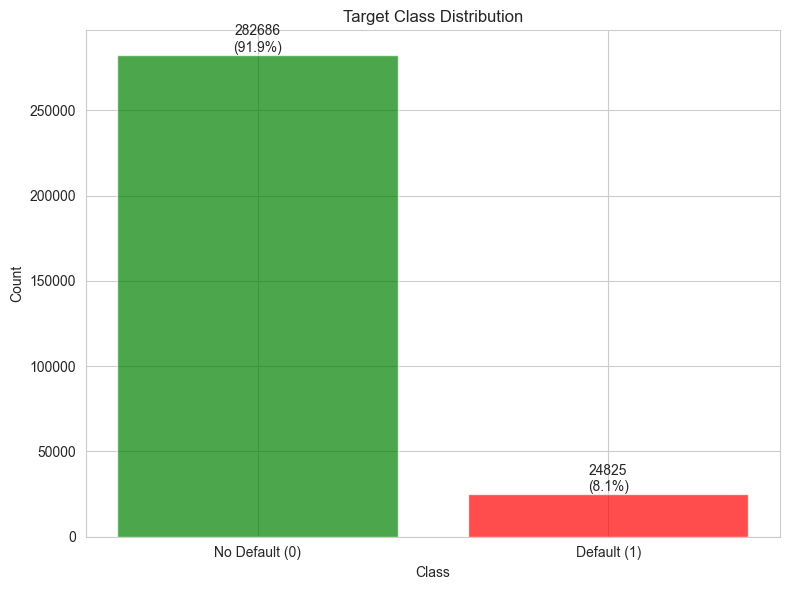

In [8]:
# ------------------------------------------------------------
# Cell 6: Target variable distribution
# ------------------------------------------------------------
plot_class_distribution(df['TARGET'], save_path='../outputs/target_distribution.png')

In [9]:
# ------------------------------------------------------------
# Cell 7: Numerical features statistics
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("NUMERICAL FEATURES STATISTICS")
print("=" * 80)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'TARGET']

print(f"\nNumber of numerical features: {len(numerical_cols)}")
print("\nBasic statistics for numerical features:")
print(df[numerical_cols[:5]].describe())


NUMERICAL FEATURES STATISTICS

Number of numerical features: 221

Basic statistics for numerical features:
       NAME_CONTRACT_TYPE  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
count        3.075110e+05  3.075110e+05     3.075110e+05  3.075110e+05   
mean        -6.927255e-17 -9.260987e-17     6.146264e-17 -4.815343e-17   
std          1.000002e+00  1.000002e+00     1.000002e+00  1.000002e+00   
min         -3.243953e-01 -7.179135e-01    -1.504820e+00 -5.775378e-01   
25%         -3.243953e-01 -7.179135e-01    -1.504820e+00 -5.775378e-01   
50%         -3.243953e-01 -7.179135e-01     6.645314e-01 -5.775378e-01   
75%         -3.243953e-01  1.392925e+00     6.645314e-01  8.072731e-01   
max          3.082659e+00  1.392925e+00     6.645314e-01  2.573387e+01   

       AMT_INCOME_TOTAL  
count      3.075110e+05  
mean      -1.229253e-17  
std        1.000002e+00  
min       -6.036870e-01  
25%       -2.374210e-01  
50%       -9.129414e-02  
75%        1.421293e-01  
max        4.9270

In [10]:
# Cell 8: Categorical features analysis
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 80)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumber of categorical features: {len(categorical_cols)}")

if len(categorical_cols) > 0:
    print("\nUnique values in categorical features (first 10):")
    for col in categorical_cols[:10]:
        print(f"{col}: {df[col].nunique()} unique values")
else:
    print("No categorical columns remaining after preprocessing (all encoded).")


CATEGORICAL FEATURES ANALYSIS

Number of categorical features: 0
No categorical columns remaining after preprocessing (all encoded).


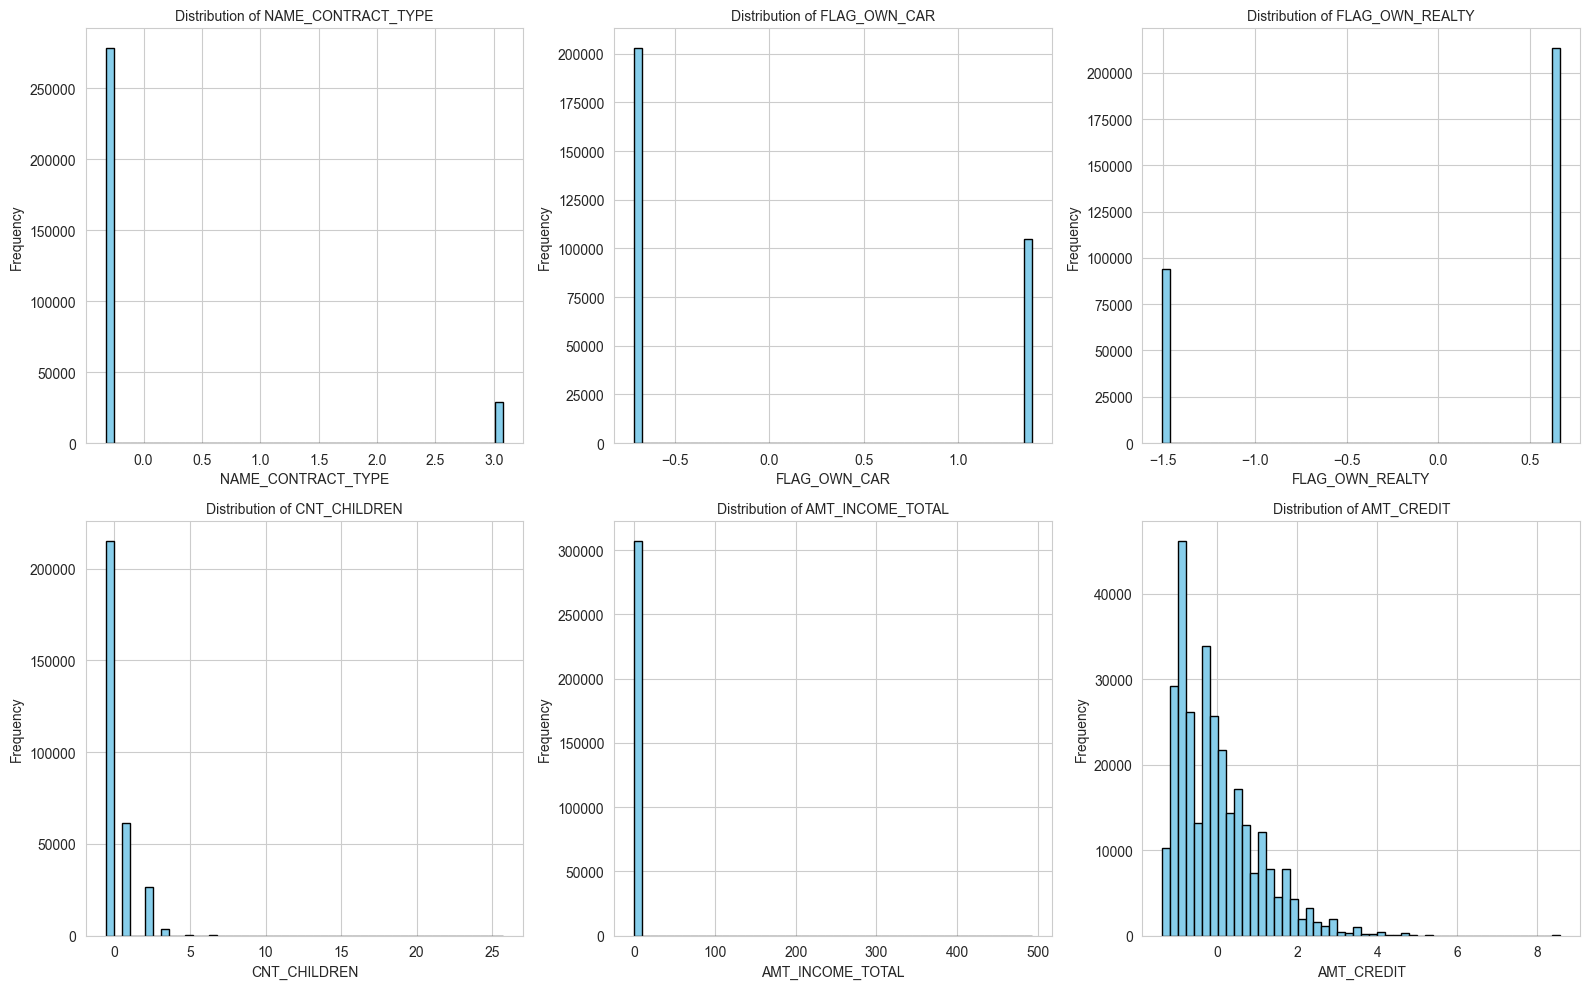

In [11]:
# ------------------------------------------------------------
# Cell 9: Visualize numerical feature distributions
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:6]):
    df[col].hist(bins=50, ax=axes[idx], color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}', fontsize=10)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


CORRELATION ANALYSIS

Top 10 features most correlated with TARGET:
TARGET               1.000000
DAYS_BIRTH           0.078239
DAYS_ID_PUBLISH      0.051457
FLAG_EMP_PHONE       0.045982
DAYS_REGISTRATION    0.041975
CNT_CHILDREN         0.019187
FLAG_MOBIL           0.000534
AMT_INCOME_TOTAL    -0.003982
FLAG_OWN_REALTY     -0.006148
AMT_ANNUITY         -0.012817
FLAG_OWN_CAR        -0.021851
Name: TARGET, dtype: float64

Top 10 features most negatively correlated with TARGET:
FLAG_MOBIL                    0.000534
AMT_INCOME_TOTAL             -0.003982
FLAG_OWN_REALTY              -0.006148
AMT_ANNUITY                  -0.012817
FLAG_OWN_CAR                 -0.021851
AMT_CREDIT                   -0.030369
NAME_CONTRACT_TYPE           -0.030896
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039628
DAYS_EMPLOYED                -0.044932
Name: TARGET, dtype: float64


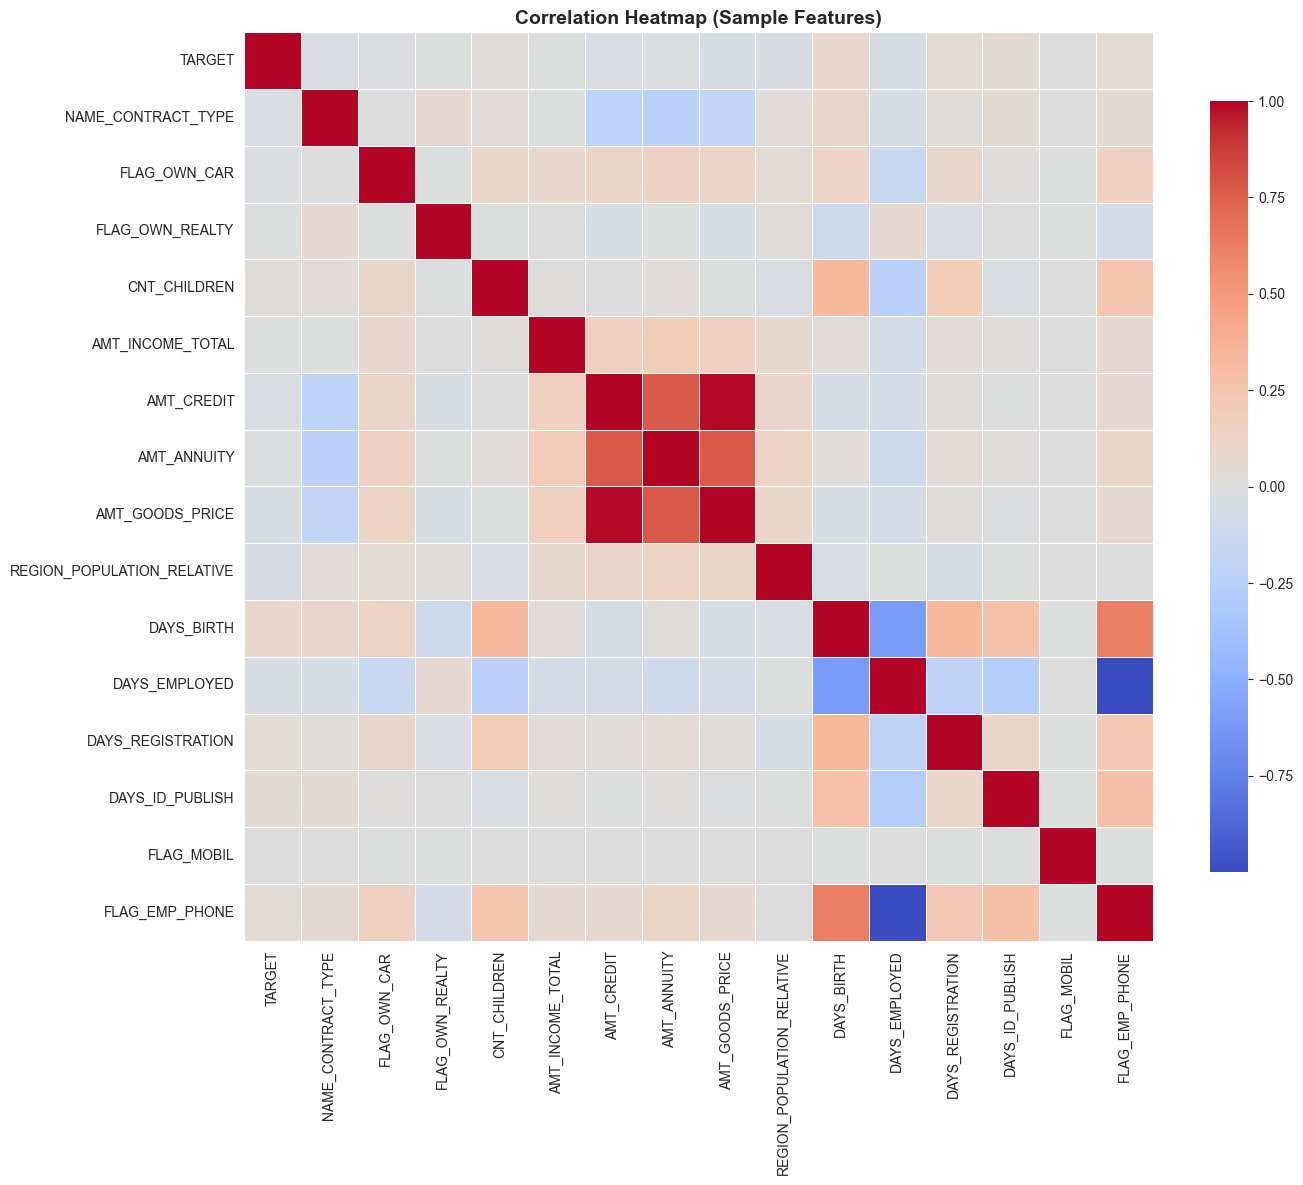

In [12]:
# Cell 10: Correlation analysis
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

corr_cols = ['TARGET'] + numerical_cols[:15]
corr_matrix = df[corr_cols].corr()

# Find top correlations with TARGET
target_corr = corr_matrix['TARGET'].sort_values(ascending=False)
print("\nTop 10 features most correlated with TARGET:")
print(target_corr.head(11))  # includes TARGET itself

print("\nTop 10 features most negatively correlated with TARGET:")
print(target_corr.tail(10))

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap (Sample Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


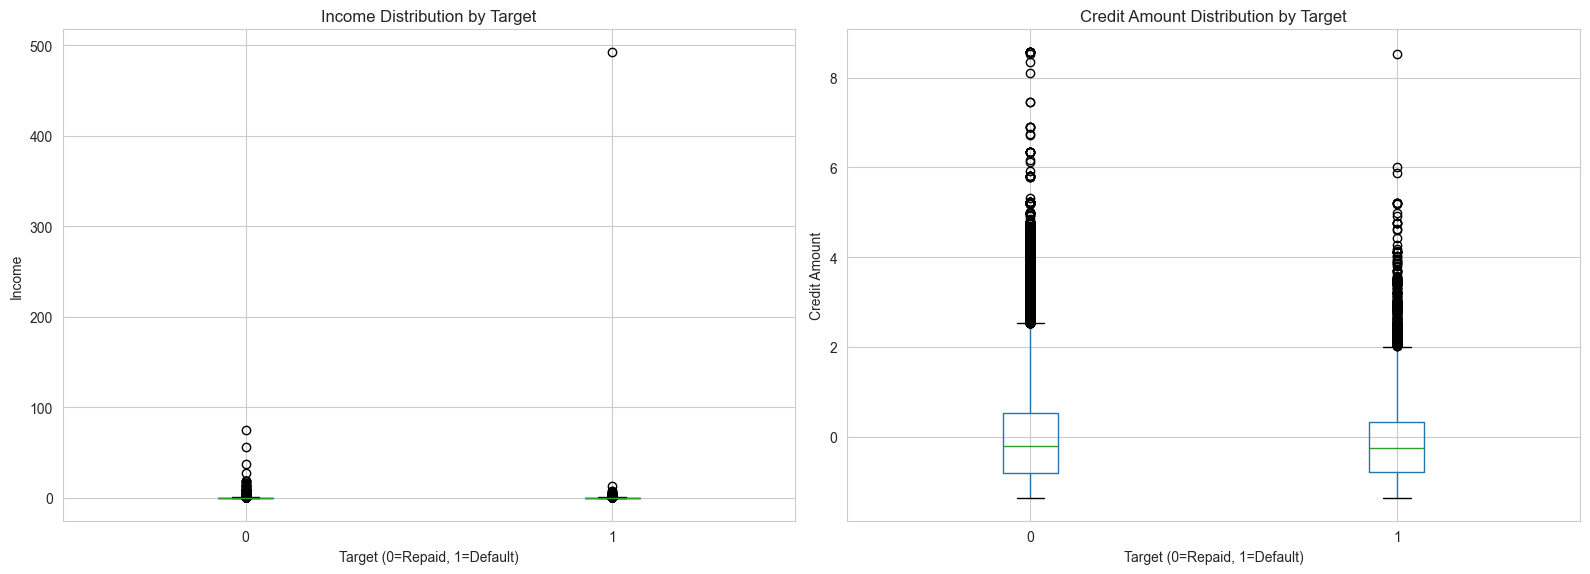

In [13]:
# Cell 11: Income vs Credit Analysis
# ------------------------------------------------------------
if 'AMT_INCOME_TOTAL' in df.columns and 'AMT_CREDIT' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    df.boxplot(column='AMT_INCOME_TOTAL', by='TARGET', ax=axes[0])
    axes[0].set_title('Income Distribution by Target')
    axes[0].set_xlabel('Target (0=Repaid, 1=Default)')
    axes[0].set_ylabel('Income')
    
    df.boxplot(column='AMT_CREDIT', by='TARGET', ax=axes[1])
    axes[1].set_title('Credit Amount Distribution by Target')
    axes[1].set_xlabel('Target (0=Repaid, 1=Default)')
    axes[1].set_ylabel('Credit Amount')
    
    plt.suptitle('')
    plt.tight_layout()
    plt.savefig('../outputs/income_credit_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

In [14]:
# Cell 12: Save preprocessed data
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("SAVING PREPROCESSED DATA")
print("=" * 80)

# Convert to numpy arrays
X_train = X_train_df.values
X_test = X_test_df.values
feature_names = X_train_df.columns.tolist()

# Save to numpy arrays
np.save('../data/X_train.npy', X_train)
np.save('../data/X_test.npy', X_test)
np.save('../data/y_train.npy', y_train)
np.save('../data/test_ids.npy', test_ids)

# Save feature names
with open('../data/feature_names.txt', 'w') as f:
    for name in feature_names:
        f.write(f"{name}\n")

print("✓ Preprocessed data saved successfully!")
print("  - X_train.npy")
print("  - X_test.npy")
print("  - y_train.npy")
print("  - test_ids.npy")
print("  - feature_names.txt")



SAVING PREPROCESSED DATA
✓ Preprocessed data saved successfully!
  - X_train.npy
  - X_test.npy
  - y_train.npy
  - test_ids.npy
  - feature_names.txt


In [15]:
# Cell 13: Summary
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("EDA & PREPROCESSING COMPLETE")
print("=" * 80)
print(f"""
Summary:
--------
✓ Original dataset shape (merged from pipeline): {df.shape}
✓ Preprocessed training samples: {X_train.shape[0]:,}
✓ Preprocessed test samples: {X_test.shape[0]:,}
✓ Final feature count: {X_train.shape[1]}
✓ Class imbalance ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1

Next Steps:
-----------
→ Run 02_Model_Training.ipynb to train ML models
→ Run 03_Clustering_Analysis.ipynb for cluster-based analysis
""")


EDA & PREPROCESSING COMPLETE

Summary:
--------
✓ Original dataset shape (merged from pipeline): (307511, 257)
✓ Preprocessed training samples: 307,511
✓ Preprocessed test samples: 48,744
✓ Final feature count: 256
✓ Class imbalance ratio: 11.39:1

Next Steps:
-----------
→ Run 02_Model_Training.ipynb to train ML models
→ Run 03_Clustering_Analysis.ipynb for cluster-based analysis

